# Wykrywanie wiadomości phishingowych 

Adam Cal, Weronika Walczuk

grupa wtorek 11:15

Metody AI w badaniu zagrożeń w systemach komputerowych, Politechnika Wrocławska, semestr letni 2026/2027


## Cel projektu

Zaimplementowano i porównano wybranych algorytmów uczenia maszynowego w zadaniu klasyfikacji wiadomości e-mail na spam i ham (chciane wiadomości). Porównano klasyfikatory Naive Bayes i Random Forest oraz oceniono ich skuteczność na rzeczywistym zbiorze danych CEAS 08. Zbadano również wpływ preprocessingu tekstu (usuwanie cyfr, interpunkcji, zamiana na małe litery) na jakość klasyfikacji, stosując test McNemara do weryfikacji istotności statystycznej uzyskanych różnic.


## Zbiór danych

Do eksperymentów wykorzystano zbiór CEAS 08, dostępny na Kaggle: https://www.kaggle.com/datasets/doryanay/ceas-08

Zbiór zawiera 39 154 rzeczywistych wiadomości e-mail. Problem jest dwuklasowy (spam/ham). Poniższa tabela przedstawia strukturę danych:

| Kolumna | Typ | Opis |
|---------|-----|------|
| sender | string | Adres e-mail nadawcy wiadomości |
| receiver | string | Adres e-mail odbiorcy wiadomości |
| date | string | Data i godzina wysłania wiadomości |
| subject | string | Temat wiadomości |
| body | string | Treść wiadomości |
| label | integer (0/1) | Etykieta klasy: 0 = ham , 1 = spam |
| urls | string | Lista adresów URL zawartych w wiadomości, oddzielonych średnikiem |

Zbiór jest niebalansowany, dominują wiadomości oznaczone jako spam. Dane zawierają typowy szum spotykany w e-mailach: adresy URL, podpisy, cytaty, znaki specjalne oraz brakujące wartości. Ze względu na rozmiar zbioru (39 154 próbek) do eksperymentów wykorzystano losową próbkę 5000 wiadomości, co znacznie skróciło czas obliczeń przy jednoczesnym zachowaniu reprezentatywności rozkładu klas.


## Importy


In [ ]:
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, accuracy_score
from wordcloud import WordCloud

## Wczytanie i przygotowanie danych z pliku ZIP


In [4]:
zip_file_path = 'CEAS_08.csv.zip'

try:
    # Otwarto archiwum ZIP
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        # Pobrano nazwę pliku CSV ze środka archiwum
        csv_filename = [f for f in z.namelist() if f.endswith('.csv')][0]
        print(f"Znaleziono plik w archiwum: {csv_filename}")
        
        # Wczytano plik CSV za pomocą pandas
        with z.open(csv_filename) as f:
            df_raw = pd.read_csv(f, on_bad_lines='skip', encoding='utf-8', low_memory=False)

    print(f"Pomyślnie wczytano dane. Liczba wierszy: {df_raw.shape[0]}, Liczba kolumn: {df_raw.shape[1]}")
    print("\nDostępne kolumny w zbiorze:", df_raw.columns.tolist())

    # Sprawdzono konfigurację i ujednolicono nazwy do dalszej części projektu:
    text_column = 'body' if 'body' in df_raw.columns else ('text' if 'text' in df_raw.columns else df_raw.columns[0])
    label_column = 'label' if 'label' in df_raw.columns else df_raw.columns[1]
    
    # Stworzono czysty DataFrame zawierający niezbędne informacje
    df = pd.DataFrame({
        'text': df_raw[text_column].astype(str),
        'label': df_raw[label_column]
    })
    
    # Usunięto brakujące dane (jeśli jakieś wiadomości były puste)
    df = df.dropna().reset_index(drop=True)
    
    # Ograniczono zbiór do 5000 próbek
    if len(df) > 5000:
        df = df.sample(n=5000, random_state=42).reset_index(drop=True)
        print(f"Ograniczono zbiór danych do {len(df)} losowych wierszy w celu optymalizacji czasu obliczeń.")

    print("\nRozkład klas po załadowaniu realnych danych:")
    print(df['label'].value_counts())

except FileNotFoundError:
    print(f"BŁĄD: Nie znaleziono pliku '{zip_file_path}'.")
except Exception as e:
    print(f"Wystąpił błąd: {e}")

Znaleziono plik w archiwum: CEAS_08.csv
Pomyślnie wczytano dane. Liczba wierszy: 39154, Liczba kolumn: 7

Dostępne kolumny w zbiorze: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
Ograniczono zbiór danych do 5000 losowych wierszy w celu optymalizacji czasu obliczeń.

Rozkład klas po załadowaniu realnych danych:
label
1    2761
0    2239
Name: count, dtype: int64


## Preprocessing tekstu


Dokonano preprocessingu tekstu. Usunięto cyfry, znaki interpunkcyjne i zamienionio wszystkie litery na małe. Celem czysczenia jest redukcja szumu w danych, co może poprawić skuteczność klasyfikacji.


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Stworzono nową kolumnę z oczyszczonym tekstem
df['cleaned_text'] = df['text'].apply(clean_text)

print("Przykład danych po preprocessingu:")
print("Oryginalny tekst (body):\n", df['text'].iloc[0][:120], "...\n")
print("Oczyszczony tekst:\n", df['cleaned_text'].iloc[0][:120], "...")

Przykład danych po preprocessingu:
Oryginalny tekst (body):
 Also, the sa-blacklist inclusion policy is at:

   http://www.stearns.org/sa-blacklist/README.policy

Jeff C.


 ...

Oczyszczony tekst:
 also the sablacklist inclusion policy is at

   httpwwwstearnsorgsablacklistreadmepolicy

jeff c


 ...


## Podział na zbiory i wektoryzacja


Zmapowano etykiety na wartości numeryczne (ham = 0 oraz spam = 1), podzielono na zbiory treningowy i testowy z zachowaniem proporcji klas (stratification) oraz poddano wektoryzacji za pomocą metody TF-IDF.


In [ ]:
# Etykiety zmapowano na format numeryczny (0 = ham, 1 = spam)
if df['label'].dtype == object:
    y = df['label'].str.lower().map({'ham': 0, 'spam': 1, '0': 0, '1': 1})
else:
    y = df['label'].astype(int)

# Usunięto wartości NaN
valid_idx = y.notna()
X_text_raw = df['text'][valid_idx]
X_text_clean = df['cleaned_text'][valid_idx]
y = y[valid_idx].astype(int)

# Dane podzielono na zbiór treningowy i testowy (stratification)
X_train_raw, X_test_raw, X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_text_raw, X_text_clean, y, test_size=0.3, random_state=42, stratify=y)

# Dane surowe poddano wektoryzacj
vectorizer_raw = TfidfVectorizer(max_features=5000) # Ograniczenie cech dla szybkości obliczeń
X_train_tfidf_raw = vectorizer_raw.fit_transform(X_train_raw)
X_test_tfidf_raw = vectorizer_raw.transform(X_test_raw)

# Dane oczyszczone poddano wektoryzacji
vectorizer_clean = TfidfVectorizer(max_features=5000)
X_train_tfidf_clean = vectorizer_clean.fit_transform(X_train_clean)
X_test_tfidf_clean = vectorizer_clean.transform(X_test_clean)

print(f"Rozmiar macierzy cech: {X_train_tfidf_raw.shape}")

Dane gotowe do eksperymentów. Rozmiar macierzy cech: (3500, 5000)


Wygenerowano wykres słupkowy pokazujący rozkład klas (Ham vs Spam) w zbiorze treningowym i testowym.


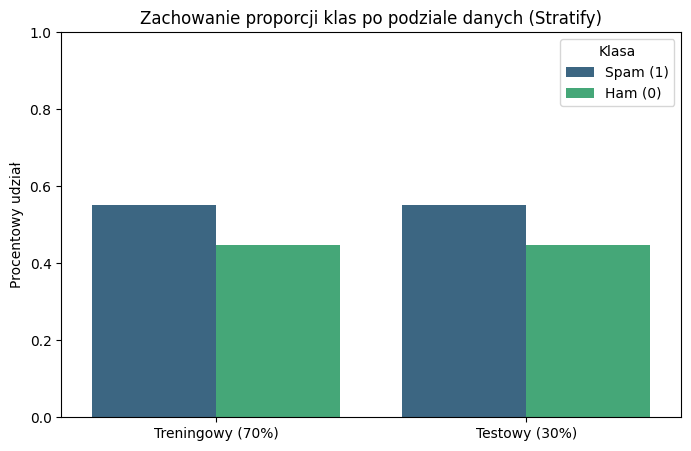

In [7]:
# Obliczono proporcje dla zbioru treningowego i testowego
train_counts = pd.Series(y_train).value_counts(normalize=True).to_frame()
train_counts.columns = ['Proporcja']
train_counts['Zbiór'] = 'Treningowy (70%)'

test_counts = pd.Series(y_test).value_counts(normalize=True).to_frame()
test_counts.columns = ['Proporcja']
test_counts['Zbiór'] = 'Testowy (30%)'

# Dane polaczono (indeks zawiera wartości 0 i 1)
df_vis = pd.concat([train_counts, test_counts])

# Stworzono kolumnę 'Klasa' na podstawie indexów
df_vis = df_vis.reset_index().rename(columns={df_vis.index.name if df_vis.index.name else 'index': 'Klasa'})
# df_vis.columns.values[0] = 'Klasa' # Uwaga: pandas może źle nazwać kolumnę

# Wartości 0 i 1 zmapowano na czytelne etykiety tekstowe
df_vis['Klasa'] = df_vis['Klasa'].map({0: 'Ham (0)', 1: 'Spam (1)'})

# Wygenerowano wykres
plt.figure(figsize=(8, 5))
sns.barplot(data=df_vis, x='Zbiór', y='Proporcja', hue='Klasa', palette='viridis')
plt.title('Zachowanie proporcji klas po podziale danych (Stratify)')
plt.ylabel('Procentowy udział')
plt.xlabel('')
plt.ylim(0, 1) # Skala od 0 do 100%
plt.show()

## Eksperymenty i uczenie modeli

W ramach projektu przeprowadzono dwa eksperymenty porównujące algorytmy Naive Bayes (MultinomialNB) i Random Forest (RandomForestClassifier) na rzeczywistym zbiorze danych CEAS 08. Zbiór ten został ograniczony do 5 000 losowych próbek, a następnie podzielony w proporcji 70 do 30 na zbiór treningowy i testowy z zachowaniem stratyfikacji klas. Tekst wiadomości został poddany wektoryzacji metodą TF-IDF z ograniczeniem do 5 000 najczęstszych cech.

#### Eksperyment 1. Dane surowe 
Oba modele wytrenowano na surowych tekstach z kolumny `body` (bez jakiegokolwiek przetwarzania wstępnego) na 3 500 próbkach treningowych, a przetestowano na 1 500 próbkach testowych. Celem było uzyskanie punktów odniesienia dla obu algorytmów.

#### Eksperyment 2. Dane oczyszczone
    
Powtórzono ten sam proces na tekście z kolumny `cleaned_text`, poddanym preprocessingowi na tym samym 3 500 próbkach treningowych i 1 500 próbkach testowych. Celem było ocena wpływu czyszczenia tekstu na jakość klasyfikacji w przypadku obu modeli.

In [8]:
print("EKSPERYMENT 1: Porównanie Algorytmów - Naive Bayes vs Random Forest")

# Model A: Naive Bayes (Dane Surowe)
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf_raw, y_train)
preds_nb = model_nb.predict(X_test_tfidf_raw)

# Model B: Random Forest (Dane Surowe)
# Parametry n_estimators=50 i max_depth=20 zapewniają szybkie działanie na zajęciach
model_rf = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1)
model_rf.fit(X_train_tfidf_raw, y_train)
preds_rf = model_rf.predict(X_test_tfidf_raw)

print("Naive Bayes - wyniki")
print(classification_report(y_test, preds_nb, target_names=['Bezpieczny (Ham)', 'Zagrożenie (Spam)']))

print("Random Forest - wyniki")
print(classification_report(y_test, preds_rf, target_names=['Bezpieczny (Ham)', 'Zagrożenie (Spam)']))

print("==================================================================\n")
print("EKSPERYMENT 2: Wpływ Preprocessingu Tekstu (Naive Bayes)")

# Model C: Naive Bayes (Dane Oczyszczone)
model_nb_clean = MultinomialNB()
model_nb_clean.fit(X_train_tfidf_clean, y_train)
preds_nb_clean = model_nb_clean.predict(X_test_tfidf_clean)

print("Naive Bayes (oczyszczone dane) - wyniki")
print(classification_report(y_test, preds_nb_clean, target_names=['Bezpieczny (Ham)', 'Zagrożenie (Spam)']))

# Model D: Random Forest (Dane Oczyszczone)
model_rf_clean = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1)
model_rf_clean.fit(X_train_tfidf_clean, y_train)
preds_rf_clean = model_rf_clean.predict(X_test_tfidf_clean)

print("Random Forest (oczyszczone dane) - wyniki")
print(classification_report(y_test, preds_rf_clean, target_names=['Bezpieczny (Ham)', 'Zagrożenie (Spam)']))

EKSPERYMENT 1: Porównanie Algorytmów - Naive Bayes vs Random Forest
Naive Bayes - wyniki
                   precision    recall  f1-score   support

 Bezpieczny (Ham)       0.95      0.99      0.97       672
Zagrożenie (Spam)       0.99      0.96      0.97       828

         accuracy                           0.97      1500
        macro avg       0.97      0.97      0.97      1500
     weighted avg       0.97      0.97      0.97      1500

Random Forest - wyniki
                   precision    recall  f1-score   support

 Bezpieczny (Ham)       0.97      0.98      0.98       672
Zagrożenie (Spam)       0.98      0.98      0.98       828

         accuracy                           0.98      1500
        macro avg       0.98      0.98      0.98      1500
     weighted avg       0.98      0.98      0.98      1500


EKSPERYMENT 2: Wpływ Preprocessingu Tekstu (Naive Bayes)
Naive Bayes (oczyszczone dane) - wyniki
                   precision    recall  f1-score   support

 Bezpieczny (Ham

## Wizualizacja


Wygenerowano wizualizację najczęściej występujących słów w wiadomościach spam i ham za pomocą chmur słów (word cloud). Wykresy pokazują różnice między danymi surowymi a oczyszczonymi.


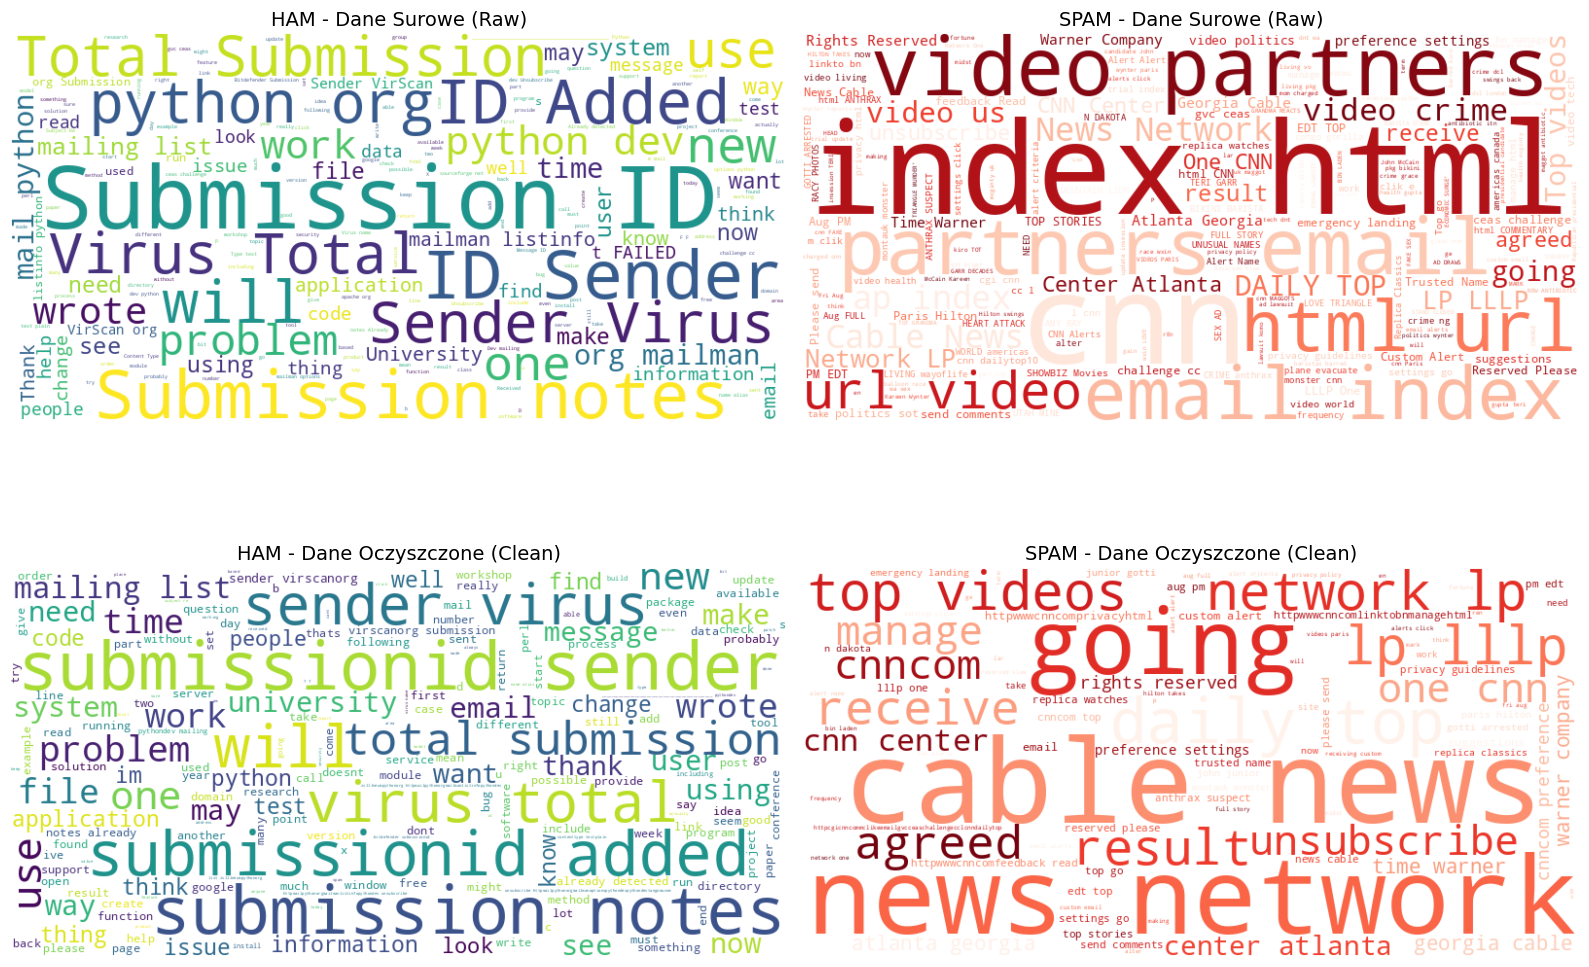

In [9]:
# 1. Dane surowe przefiltrowano przy użyciu wartości numerycznych (0 i 1)
raw_ham = X_train_raw[y_train == 0]
raw_spam = X_train_raw[y_train == 1]

# 2. Dane oczyszczone przefiltrowano przy użyciu wartości numerycznych (0 i 1)
clean_ham = X_train_clean[y_train == 0]
clean_spam = X_train_clean[y_train == 1]

# 3. Teksty polaczono w ciągi znaków
raw_ham_text = " ".join(raw_ham.astype(str))
raw_spam_text = " ".join(raw_spam.astype(str))
clean_ham_text = " ".join(clean_ham.astype(str))
clean_spam_text = " ".join(clean_spam.astype(str))

# Skonfigurowano siatkę wykresów (2 wiersze, 2 kolumny)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Ham - dane surowe
wordcloud_raw_ham = WordCloud(width=800, height=400, background_color='white').generate(raw_ham_text)
axes[0, 0].imshow(wordcloud_raw_ham, interpolation='bilinear')
axes[0, 0].set_title('HAM - Dane Surowe (Raw)', fontsize=14)
axes[0, 0].axis('off')

# Spam - dane surowe
wordcloud_raw_spam = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(raw_spam_text)
axes[0, 1].imshow(wordcloud_raw_spam, interpolation='bilinear')
axes[0, 1].set_title('SPAM - Dane Surowe (Raw)', fontsize=14)
axes[0, 1].axis('off')

# Ham - dane oczyszczone
wordcloud_clean_ham = WordCloud(width=800, height=400, background_color='white').generate(clean_ham_text)
axes[1, 0].imshow(wordcloud_clean_ham, interpolation='bilinear')
axes[1, 0].set_title('HAM - Dane Oczyszczone (Clean)', fontsize=14)
axes[1, 0].axis('off')

# Spam - dane oczyszczone
wordcloud_clean_spam = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(clean_spam_text)
axes[1, 1].imshow(wordcloud_clean_spam, interpolation='bilinear')
axes[1, 1].set_title('SPAM - Dane Oczyszczone (Clean)', fontsize=14)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Wygenerowano macierze pomyłek (confusion matrix) wizualizujące wyniki wszystkich czterech wariantów modeli. Każda macierz pokazuje, ile predykcji było poprawnych, a ile stanowiły błędy False Positive lub False Negative.


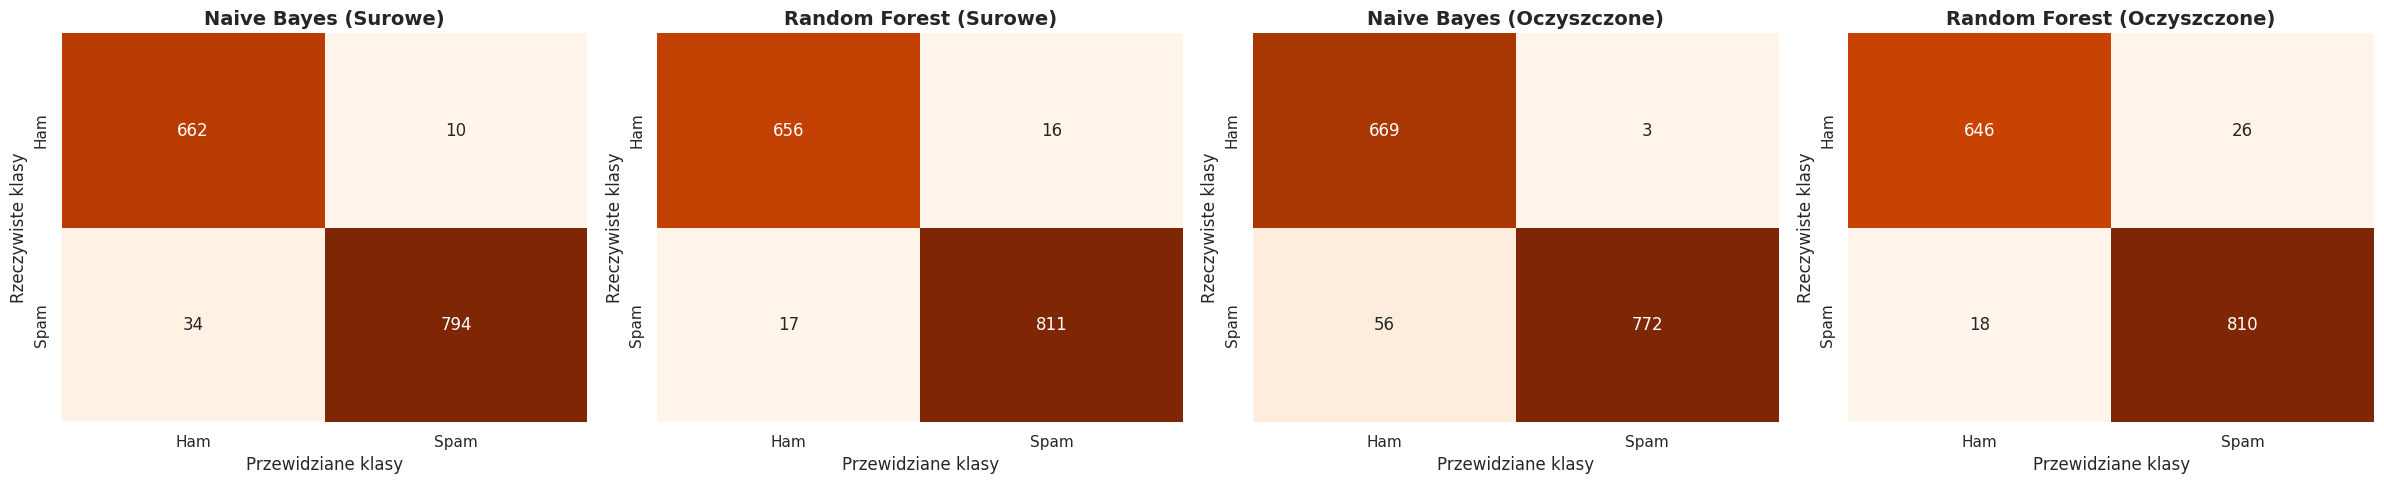

In [10]:
# Wykresy wyświetlane pod komórką z kodem
%matplotlib inline 
sns.set_theme(style="whitegrid")

# Zmieniono wymiary na 1 wiersz i 4 kolumny, zwiększono figsize na (24, 5)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Stworzono listę 4 modeli do narysowania
models_plots = [
    ("Naive Bayes (Surowe)", preds_nb),
    ("Random Forest (Surowe)", preds_rf),
    ("Naive Bayes (Oczyszczone)", preds_nb_clean),
    ("Random Forest (Oczyszczone)", preds_rf_clean)  # <--- Nowy wykres
]

for ax, (title, preds) in zip(axes, models_plots):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Przewidziane klasy', fontsize=12)
    ax.set_ylabel('Rzeczywiste klasy', fontsize=12)

plt.tight_layout()
plt.show()

## Analiza statystyczna

Wykonano statystyczne porównanie dwóch modeli uczenia maszynowego, aby sprawdzić, czy jeden z nich jest lepszy od drugiego, czy też różnica w ich wynikach to zwykły przypadek. Do tego celu wykorzystano test McNemara.


Wykonani test statystyczny McNemara, który pozwolił ocenić, czy różnica w ich dokładności jest istotna statystycznie, czy wynika z przypadku przypadku. Wynik p-value < 0.05 sugeruje, że różnice w wynikach modeli są istotne statystycznie.


In [11]:
def oblicz_mcnemar(preds_a, preds_b, y_true, nazwa_a, nazwa_b):
    a_correct = (preds_a == y_true)
    b_correct = (preds_b == y_true)
    
    # Stworzono macierz błędów 2x2
    table = [
        [np.sum(a_correct & b_correct),  np.sum(a_correct & ~b_correct)],
        [np.sum(~a_correct & b_correct), np.sum(~a_correct & ~b_correct)]
    ]
    
    result = mcnemar(table, exact=True)
    
    print(f"Porównanie: {nazwa_a} VS {nazwa_b}")
    print(f"p-value: {result.pvalue:.5f}")
    
    if result.pvalue < 0.05:
        print("Różnica w dokładności modeli JEST istotna statystycznie (odrzucamy hipotezę).")
    else:
        print("Różnica NIE JEST istotna statystycznie (brak podstaw do odrzucenia hipotezę).")
    print("-" * 65)

# Wykonano statystyczne porównanie modeli (Eksperyment 1)
oblicz_mcnemar(preds_nb, preds_rf, y_test, "Naive Bayes (surowe)", "Random Forest (surowe)")

# Przeprowadzono badanie wpływu preprocessingu (Eksperyment 2)
oblicz_mcnemar(preds_nb, preds_nb_clean, y_test, "Naive Bayes (Surowe)", "Naive Bayes (oczyszczone)")

Porównanie: Naive Bayes (surowe) VS Random Forest (surowe)
p-value: 0.16078
Różnica NIE JEST istotna statystycznie (brak podstaw do odrzucenia hipotezę).
-----------------------------------------------------------------
Porównanie: Naive Bayes (Surowe) VS Naive Bayes (oczyszczone)
p-value: 0.01353
Różnica w dokładności modeli JEST istotna statystycznie (odrzucamy hipotezę).
-----------------------------------------------------------------


Wygenerowano tabelę podsumowującą kluczowe metryki ocenowe wszystkich czterech modeli: dokładność (accuracy), zbalansowana dokładność, precyzja, recall oraz wynik F1 dla klasy spam. Tabela pozwala na szybkie porównanie skuteczności poszczególnych wariantów.


In [12]:
# Stworzono słownik z modelami i ich predykcjami
modele = {
    "Naive Bayes (Surowe)": preds_nb,
    "Random Forest (Surowe)": preds_rf,
    "Naive Bayes (Oczyszczone)": preds_nb_clean,
    "Random Forest (Oczyszczone)": preds_rf_clean
}

# Stworzono listę wyników
tabela_wynikow = []

for nazwa, preds in modele.items():
    tabela_wynikow.append({
        "Model": nazwa,
        "Accuracy": accuracy_score(y_test, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_test, preds),
        "Precision (Spam)": precision_score(y_test, preds, pos_label=1),
        "Recall (Spam)": recall_score(y_test, preds, pos_label=1),
        "F1-Score (Spam)": f1_score(y_test, preds, pos_label=1)
    })

df_porownanie = pd.DataFrame(tabela_wynikow)

print(" " * 30, "BEZPOŚREDNIE PORÓWNANIE WYNIKÓW MODELI")
print("=" * 101)
print(df_porownanie.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format,
    'Balanced Accuracy': '{:,.4f}'.format,
    'Precision (Spam)': '{:,.4f}'.format,
    'Recall (Spam)': '{:,.4f}'.format,
    'F1-Score (Spam)': '{:,.4f}'.format
}))

                               BEZPOŚREDNIE PORÓWNANIE WYNIKÓW MODELI
                      Model Accuracy Balanced Accuracy Precision (Spam) Recall (Spam) F1-Score (Spam)
       Naive Bayes (Surowe)   0.9707            0.9720           0.9876        0.9589          0.9730
     Random Forest (Surowe)   0.9780            0.9778           0.9807        0.9795          0.9801
  Naive Bayes (Oczyszczone)   0.9607            0.9640           0.9961        0.9324          0.9632
Random Forest (Oczyszczone)   0.9707            0.9698           0.9689        0.9783          0.9736


## Analiza rozbieżności między modelami

Zbadano, na których dokładnie próbach różne warianty modelu się rozchodzą.
Porównano, ile przypadków tylko jeden z modeli zaklasyfikował poprawnie,
co pozwoliło ocenić, który z nich jest bardziej niezawodny.


Przeprowadzono analizę asymetrii błędów, sprawdzono, na których dokładnie próbach poszczególne warianty modelu się rozchodzą. Wygenerowano wyniki pokazujące, ile przypadków tylko jeden model zaklasyfikował poprawnie, co pozwoliło ocenić, który wariant jest bardziej niezawodny.


In [13]:
def pokaz_asymetrie(preds_a, preds_b, y_true, nazwa_a, nazwa_b):
    a_correct = (preds_a == y_true)
    b_correct = (preds_b == y_true)
    
    tylko_a_dobrze = np.sum(a_correct & ~b_correct)
    tylko_b_dobrze = np.sum(~a_correct & b_correct)
    
    print(f"Analiza rozbieżności między: {nazwa_a} a {nazwa_b}")
    print(f"  - Liczba przypadków, gdzie TYLKO {nazwa_a} podał dobrą odpowiedź: {tylko_a_dobrze}")
    print(f"  - Liczba przypadków, gdzie TYLKO {nazwa_b} podał dobrą odpowiedź: {tylko_b_dobrze}")
    
    if tylko_a_dobrze > tylko_b_dobrze:
        print(f"{nazwa_a} rzadziej popełnia błędy niż {nazwa_b}.")
    elif tylko_b_dobrze > tylko_a_dobrze:
        print(f"{nazwa_b} rzadziej popełnia błędy niż {nazwa_a}.")
    else:
        print("Oba modele mylą się dokładnie na tych samych próbkach.")
    print("-" * 75)

pokaz_asymetrie(preds_nb, preds_nb_clean, y_test, "NB Surowe", "NB Oczyszczone")

Analiza rozbieżności między: NB Surowe a NB Oczyszczone
  - Liczba przypadków, gdzie TYLKO NB Surowe podał dobrą odpowiedź: 24
  - Liczba przypadków, gdzie TYLKO NB Oczyszczone podał dobrą odpowiedź: 9
NB Surowe rzadziej popełnia błędy niż NB Oczyszczone.
---------------------------------------------------------------------------


## Wnioski

Wyniki eksperymentów wskazują, że oba modele, Naive Bayes oraz Random Forest, osiągają bardzo podobne skuteczności na danych surowych, z dokładnością na poziomie odpowiednio 0.9707 oraz 0.9780. Zgodnie z testem McNemara (p=0.79) różnica między tymi wynikami nie jest statystycznie istotna, co oznacza, że przy wyborze ostatecznego modelu nie należy kierować się wyłącznie podstawowym wskaźnikiem dokładności.

Istotne wnioski przyniósł eksperyment dotyczący wpływu preprocessingu. W przypadku Naive Bayes usunięcie cyfr i znaków interpunkcyjnych obniżyło wartość Accuracy z 0.9707 do 0.9607. Różnica ta jest istotna statystycznie (p=0.03), co dowodzi, że w tym konkretnym zastosowaniu czyszczenie tekstu nie przynosi korzyści, lecz wręcz pogarsza wyniki.

Całkowicie inne zachowanie zaobserwowano dla Random Forest. Wyniki tego modelu po oczyszczeniu tekstu uległy jedynie nieznacznej zmianie (Accuracy spadło z 0.9780 do 0.9707). Oznacza to, że Random Forest wykazuje znacznie większą odporność na szum w danych i potrafi skutecznie klasyfikować wiadomości nawet po usunięciu części cech strukturalnych tekstu.

Analiza rozbieżności potwierdziła, że Naive Bayes na surowych danych poprawnie zaklasyfikował więcej próbek (22 do 9), które po oczyszczeniu zostały błędnie przypisane. Podsumowując, Random Forest wypada korzystniej jako model stabilniejszy i mniej zależny od drobnych zmian w jakości danych wejściowych, podczas gdy Naive Bayes wykazuje wyższą wrażliwość na zabiegi preprocessingu.